# This notebook is to test the exact bayesian optimization framework proposed

## 0 - Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from numpy.linalg import inv, eigvalsh
from math import erf, sqrt, exp, pi

## 1 - Define functions to estimate EI intervals

### 1.1 - Interval helpers and arithmetic

In [2]:
def split_intervals(intervals: np.ndarray, excludedMaskPre: np.ndarray, a: float, b: float):
    """Partition strategy."""
    excludedMaskPreOut = []
    for i in range(len(excludedMaskPre)):
        excludedMaskPre_i = excludedMaskPre[i]
        if i>0:
            excludedMaskPre_i_1 = excludedMaskPre[i-1]
            if excludedMaskPre_i_1 and not(excludedMaskPre_i):
                excludedMaskPreOut.append(0)
        if i == 0 and not(excludedMaskPre_i):
            excludedMaskPreOut.append(0)
        excludedMaskPreOut.append(int(excludedMaskPre_i))
        if not(excludedMaskPre_i):
            excludedMaskPreOut.append(0)

    X = []
    XM = []
    for i in range(len(intervals)):
        L,R = intervals[i]
        if excludedMaskPre[i]:
            if L not in X:
                X.append(L)
                XM.append(0)
            if i == (len(intervals) - 1):
                X.append(R)
                XM.append(0)
        else:
            M = 0.5*(L+R)
            if i > 0: 
                if L in X and not(excludedMaskPre[i-1]):
                    X.pop()
                    XM.pop()
                else:
                    X.append(L)
                    XM.append(0)
            else:
                X.append(L)
                XM.append(0)
            X.append(float(M))
            XM.append(1)
            X.append(R)
            XM.append(0)
    X = np.array(X, dtype=float)
    XM = np.array(XM, dtype=bool)

    D = []
    for i in range(len(X)):
        if XM[i]:
            l = X[i-1]
            r = X[i+1]
            x = X[i]
            D.append(float(min(x-l, r-x)/2))
        else:
            D.append(None)

    B = []
    for i in range(len(XM)):
        if XM[i]:
            d = D[i]
            B.append(float(X[i]-d/2))
            B.append(float(X[i]+d/2))
        else:
            B.append(float(X[i]))

    intervalsOut = []
    sampledMaskOut = []
    for i in range(len(B)-1):
        L = B[i]
        R = B[i+1]
        M = 0.5*(L+R)
        intervalsOut.append((L, R))
        
        if M in X[XM]:
            sampledMaskOut.append(1)
        else:
            sampledMaskOut.append(0)

    return np.array(intervalsOut), np.array(sampledMaskOut, dtype=bool), np.array(excludedMaskPreOut, dtype=bool)


def interval_midpoints(intervals: np.ndarray):
    """Return midpoints as column vector suitable for sklearn (n,1)."""
    mids = [0.5*(L+R) for (L, R) in intervals]
    return np.array(mids, dtype=float).reshape(-1, 1)

def mul_interval_scalar(c: float, lo: float, hi: float):
    """Return bounds for c*[lo,hi]."""
    a, b = c * lo, c * hi
    return (min(a, b), max(a, b))

def add_intervals(a_lo, a_hi, b_lo, b_hi):
    """Return bounds for [a_lo,a_hi] + [b_lo,b_hi]."""
    return (a_lo + b_lo, a_hi + b_hi)

def sub_intervals(a_lo, a_hi, b_lo, b_hi):
    """Return bounds for [a_lo,a_hi] - [b_lo,b_hi]."""
    return (a_lo - b_hi, a_hi - b_lo)

def square_interval(lo: float, hi: float):
    """Return bounds for z^2 with z in [lo,hi]."""
    if lo <= 0.0 <= hi:
        return (0.0, max(lo * lo, hi * hi))
    else:
        return (min(lo * lo, hi * hi), max(lo * lo, hi * hi))
    
def forward_solve_interval_L(Lmat, Kmins, Kmaxs):
    """
    Given lower-triangular L with positive diagonal (Cholesky),
    and componentwise bounds k_i ∈ [Kmin_i, Kmax_i],
    compute tight interval bounds v_j ∈ [v_lo[j], v_hi[j]] for the solution of L v = k.

    Recurrence:
      v_1 = k_1 / L_11
      v_j = (k_j - sum_{i<j} L_{j,i} v_i) / L_{j,j}
    """
    L = np.asarray(Lmat, float)
    n = L.shape[0]
    v_lo = np.zeros(n)
    v_hi = np.zeros(n)

    for j in range(n):
        # Sum S_j = Σ_{i<j} L_{j,i} v_i, with each term interval-bounded
        S_lo, S_hi = 0.0, 0.0
        for i in range(j):
            lij = L[j, i]
            t_lo, t_hi = mul_interval_scalar(lij, v_lo[i], v_hi[i])
            S_lo, S_hi = add_intervals(S_lo, S_hi, t_lo, t_hi)

        # Numerator interval: N_j = k_j - S_j
        Kj_lo, Kj_hi = Kmins[j], Kmaxs[j]
        N_lo, N_hi = sub_intervals(Kj_lo, Kj_hi, S_lo, S_hi)

        # Divide by positive L_{j,j}
        Ljj = L[j, j]
        # since Ljj > 0 (Cholesky), division preserves order
        v_lo[j] = N_lo / Ljj
        v_hi[j] = N_hi / Ljj

    return v_lo, v_hi

### 1.2 - Std Normal CDF and PDF

In [3]:
def Phi(z: float) -> float:
    """Standard normal CDF."""
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def phi(z: float) -> float:
    """Standard normal PDF."""
    return (1.0 / sqrt(2.0 * pi)) * exp(-0.5 * z * z)

### 1.3 - RBF Kernel Bounds

In [4]:
#def rbf_K_interval(L: float, R: float, xi: float, sigma_f2: float, ell: float):
def rbf_K_interval(L: float, R: float, xi: float, gp: GaussianProcessRegressor):
    """
    Compute [K_{i,min}, K_{i,max}] for 
    k(x,xi)=sigma_f^2*exp(-(x-xi)^2/(2 ell^2)), 
    x in [L,R].
    """
    # Bounds for D_i
    Dmin = min(abs(L - xi), abs(R - xi))
    Dmax = max(abs(L - xi), abs(R - xi))
    # Calculate Kmin and Kmax using kernel from gp
    Kall = gp.kernel_([[Dmin],[Dmax]],[[0],[0]])
    KminGP = Kall[1,0]
    KmaxGP = Kall[0,0]
    # S_i = D_i^2 / (2 ell^2)
    #Smin = (Dmin ** 2) / (2.0 * ell ** 2)
    #Smax = (Dmax ** 2) / (2.0 * ell ** 2)
    # E_i = exp(-S_i) is decreasing in S_i
    #Emin = exp(-Smax)
    #Emax = exp(-Smin)
    # K_i = sigma_f^2 * E_i
    #Kmin = sigma_f2 * Emin
    #Kmax = sigma_f2 * Emax
    #return float(Kmin), float(Kmax), float(KminGP), float(KmaxGP)
    return float(KminGP), float(KmaxGP)

### 1.4 - GP Posterior Mean Bounds

In [5]:
#def gp_mu_interval_bounds(X: np.ndarray, y: np.ndarray, L: float, R: float, sigma_f2: float, ell: float, sigma_n2=0.0: float):
def gp_mu_interval_bounds(L: float, R: float, gp: GaussianProcessRegressor):
    """
    Compute [μ_lo, μ_hi] for 
    μ(x)=k(x)^T α, α = L^{-T} \\ (L \\ y), 
    x in [L,R].
    """
    #X = np.asarray(X, dtype=float).ravel()
    X = np.asarray(gp.X_train_, dtype=float).ravel()
    #y = np.asarray(y, dtype=float).ravel()
    #y = np.asarray(gp.y_train_, dtype=float).ravel()
    n = len(X)

    # Build K(X,X)
    #D2 = (X[:, None] - X[None, :]) ** 2
    #K = sigma_f2 * np.exp(- D2 / (2.0 * ell ** 2))

    # α = (K + σ_n^2 I)^(-1) y
    #A = np.linalg.solve(K + sigma_n2 * np.eye(n), np.eye(n))   # (K+σ_n^2 I)^{-1}
    #alpha = A @ y
    alpha = gp.alpha_.ravel()
    #print("alpha:", alpha)

    # Componentwise kernel intervals
    Kmins = np.empty(n, dtype=float)
    Kmaxs = np.empty(n, dtype=float)
    for i, xi in enumerate(X):
        Kmins[i], Kmaxs[i] = rbf_K_interval(L, R, xi, gp)

    # μ bounds: sum of α_i * K_i with interval multiplication
    mu_lo = 0.0
    mu_hi = 0.0
    for a, kmin, kmax in zip(alpha, Kmins, Kmaxs):
        #print("a, kmin, kmax:", a, kmin, kmax)
        #lo_i = min(a * kmin, a * kmax)
        #hi_i = max(a * kmin, a * kmax)

        lo_i, hi_i = mul_interval_scalar(a, kmin, kmax)
        mu_lo += lo_i
        mu_hi += hi_i

    #return float(mu_lo), float(mu_hi), A, Kmins, Kmaxs
    #print("mu_lo, mu_hi:", mu_lo, mu_hi)
    return float(mu_lo), float(mu_hi), Kmins, Kmaxs

### 1.5 - GP Posterior Standard Deviation Bounds

In [6]:
#def gp_sigma_interval_bounds(A: np.ndarray, Kmins: np.ndarray, Kmaxs: np.ndarray, sigma_f2: float):
def gp_sigma_interval_bounds(Kmins: np.ndarray, Kmaxs: np.ndarray, gp: GaussianProcessRegressor):
    """
    Given L = cholesky(K + σ_n^2 I) and per-component kernel 
    intervals [Kmin_i,Kmax_i] (nonnegative),
    bound v_j ∈ [v_lo[j], v_hi[j]] for the solution of L v = k, and then
    bound Q = ||v||^2,
    then σ^2 = σ_f^2 - Q, and finally σ ∈ [sqrt(max(0,σ^2_lo)), sqrt(max(0,σ^2_hi))].
    """
    #A = np.asarray(A, dtype=float)
    #n = A.shape[0]
    Kmins = np.asarray(Kmins, dtype=float)
    Kmaxs = np.asarray(Kmaxs, dtype=float)

    # Extract σ_f^2 from gp
    gp_params = gp.kernel_.get_params()
    sigma_f2 = float(gp_params['k1__constant_value'])

    # Extract L = cholesky(K + σ_n^2 I) from gp
    L_ = gp.L_

    # Calculate bounds v_j ∈ [v_lo[j], v_hi[j]] for the solution of L v = k
    v_lo, v_hi = forward_solve_interval_L(L_, Kmins, Kmaxs)

    # Diagonal terms
    #I_lo = 0.0
    #I_hi = 0.0
    #for i in range(n):
    #    aii = A[i, i]
    #    t1 = aii * (Kmins[i] ** 2)
    #    t2 = aii * (Kmaxs[i] ** 2)
    #    I_lo += min(t1, t2)
    #    I_hi += max(t1, t2)

    # Off-diagonal terms (i<j), with nonnegative intervals so [k_i*k_j] = [kmin_i*kmin_j, kmax_i*kmax_j]
    #O_lo = 0.0
    #O_hi = 0.0
    #for i in range(n):
    #    ki_min, ki_max = Kmins[i], Kmaxs[i]
    #    for j in range(i + 1, n):
    #        aij = A[i, j]
    #        kj_min, kj_max = Kmins[j], Kmaxs[j]
    #        p_min = ki_min * kj_min
    #        p_max = ki_max * kj_max
    #        t1 = 2.0 * aij * p_min
    #        t2 = 2.0 * aij * p_max
    #        O_lo += min(t1, t2)
    #        O_hi += max(t1, t2)

    #Q_min = I_lo + O_lo
    #Q_max = I_hi + O_hi

    # Q interval = sum of squares intervals (IA addition)
    Q_lo, Q_hi = 0.0, 0.0
    for lo, hi in zip(v_lo, v_hi):
        s_lo, s_hi = square_interval(lo, hi)
        Q_lo += s_lo
        Q_hi += s_hi

    # σ^2 interval: [max(0, σ_f^2 - Q_max), max(0, σ_f^2 - Q_min)]
    sig2_lo = max(0.0, sigma_f2 - Q_hi)
    sig2_hi = max(0.0, sigma_f2 - Q_lo)

    # σ interval by monotonicity of sqrt
    sig_lo = sqrt(sig2_lo)
    sig_hi = sqrt(sig2_hi)
    return float(sig_lo), float(sig_hi), float(Q_lo), float(Q_hi), (v_lo, v_hi)

### 1.6 - EI Bounds

In [7]:
def ei_interval_explicit(mu_bounds, sigma_bounds, gp: GaussianProcessRegressor):
    """
    Explicit IA bounds for EI on an interval using:
      EI = N * Phi(Z) + σ * phi(Z),  with N=f_min - μ,  Z=N/σ.
    Inputs:
      f_min        : current best observed value
      mu_bounds    : (μ_lo, μ_hi)
      sigma_bounds : (σ_lo, σ_hi) with σ_lo >= 0
    Returns:
      (EI_lo, EI_hi)
    """
    mu_lo, mu_hi = float(mu_bounds[0]), float(mu_bounds[1])
    sig_lo, sig_hi = float(sigma_bounds[0]), float(sigma_bounds[1])

    # Extract f_min from gp
    y = np.asarray(gp.y_train_, dtype=float).ravel()
    f_min = np.min(y)

    # Interval for N = f_min - μ
    N_min = f_min - mu_hi
    N_max = f_min - mu_lo

    # If σ_lo == 0, use a safe enclosure: EI increases with σ (for fixed μ), so
    # lower bound at σ=0; upper bound at (μ=μ_lo, σ=σ_hi).
    if sig_lo == 0.0:
        EI_lo = max(0.0, N_min)  # EI(μ=μ_hi, σ=0) is a lower bound
        if sig_hi > 0.0:
            Z_hi = (f_min - mu_lo) / sig_hi
            EI_hi = (f_min - mu_lo) * Phi(Z_hi) + sig_hi * phi(Z_hi)
            # Ensure nonnegativity
            EI_hi = max(EI_hi, EI_lo)
        else:
            # σ_hi is also zero → EI is exactly max(0, N)
            EI_hi = max(0.0, N_max)
        return float(EI_lo), float(EI_hi)

    # Otherwise, proceed with explicit IA through Z, Phi, phi
    # J = 1/σ ∈ [1/σ_hi, 1/σ_lo]
    J_min = 1.0 / sig_hi
    J_max = 1.0 / sig_lo

    # Z = N * J, full interval product (four corners)
    S = [N_min * J_min, N_min * J_max, N_max * J_min, N_max * J_max]
    Z_min, Z_max = min(S), max(S)

    # Phi(Z) interval (monotone)
    F_min = Phi(Z_min)
    F_max = Phi(Z_max)

    # phi(Z) interval (unimodal, symmetric)
    P_candidates = [phi(Z_min), phi(Z_max)]
    if Z_min <= 0.0 <= Z_max:
        P_candidates.append(phi(0.0))
    P_min = min(P_candidates)
    P_max = max(P_candidates)

    # U = N * Phi(Z)
    U_candidates = [
        N_min * F_min, N_min * F_max,
        N_max * F_min, N_max * F_max
    ]
    U_min, U_max = min(U_candidates), max(U_candidates)

    # V = σ * phi(Z)
    V_candidates = [
        sig_lo * P_min, sig_lo * P_max,
        sig_hi * P_min, sig_hi * P_max
    ]
    V_min, V_max = min(V_candidates), max(V_candidates)

    # EI = U + V (interval addition)
    return float(U_min + V_min), float(U_max + V_max)

### 1.7 - One-call Wrapper

In [8]:
#def ei_bounds_on_interval(L: float, R: float, X: np.ndarray, y: np.ndarray, f_min: float, sigma_f2: float, ell: float, sigma_n2=0.0: float):
def ei_bounds_on_interval(L: float, R: float, gp: GaussianProcessRegressor):
    """
    Compute EI interval [EI_lo, EI_hi] on x in [L,R], following the LaTeX sections:
      1) kernel intervals -> 2) μ interval -> 3) σ interval -> 4) EI explicit IA
    Returns:
      dict with μ_bounds, σ_bounds, Q_bounds, EI_bounds
    """
    #mu_lo, mu_hi, A, Kmins, Kmaxs = gp_mu_interval_bounds(
    #    X, y, L, R, sigma_f2, ell, sigma_n2
    #)
    mu_lo, mu_hi, Kmins, Kmaxs = gp_mu_interval_bounds(L, R, gp)
    #sig_lo, sig_hi, Q_min, Q_max = gp_sigma_interval_bounds(
    #    A, Kmins, Kmaxs, sigma_f2
    #)
    sig_lo, sig_hi, Q_min, Q_max, _ = gp_sigma_interval_bounds(Kmins, Kmaxs, gp)
    #EI_lo, EI_hi = ei_interval_explicit(
    #    f_min, (mu_lo, mu_hi), (sig_lo, sig_hi)
    #)
    EI_lo, EI_hi = ei_interval_explicit((mu_lo, mu_hi), (sig_lo, sig_hi), gp)
    return {
        "mu_bounds": (mu_lo, mu_hi),
        "sigma_bounds": (sig_lo, sig_hi),
        "Q_bounds": (Q_min, Q_max),
        "EI_bounds": (EI_lo, EI_hi),
    }

## 2 - Toy function to minimize

In [9]:
def f(x):
    return (x - 2)**2 + np.sin(5*x)

## 3 - EI Function

In [10]:
def expected_improvement(X, gp, y_min):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1,1)
    mu = mu.reshape(-1,1)
    with np.errstate(divide='warn'):
        Z = (y_min - mu) / sigma # to minimize
        ei = (y_min - mu) * norm.cdf(Z) + sigma * norm.pdf(Z) # to minimize
        ei[sigma==0.0] = 0.0
    return ei.ravel()

## 4 - Define domain

In [11]:
a, b = 0.0, 4.0

## 5 - Iteration 0

### 5.1 - Sample at center

In [12]:
intervals0 = np.array([(a,b)])
excludedMask0Post = np.array([0], dtype=bool)
sampledMask0 = np.array([0], dtype=bool)
print("Iteration 0:")
print("intervals0:\n", intervals0)
print("sampledMask0:", sampledMask0.astype(int))
print("excludedMask0Post:", excludedMask0Post.astype(int))
print("x to sample:", interval_midpoints(intervals0[np.logical_not(excludedMask0Post)]))

X = interval_midpoints(intervals0[np.logical_not(excludedMask0Post)])
y = f(X)
print("y values:", y)

Iteration 0:
intervals0:
 [[0. 4.]]
sampledMask0: [0]
excludedMask0Post: [0]
x to sample: [[2.]]
y values: [[-0.54402111]]


### 5.2 - Build GP

In [13]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6)
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 5.3 - Plot

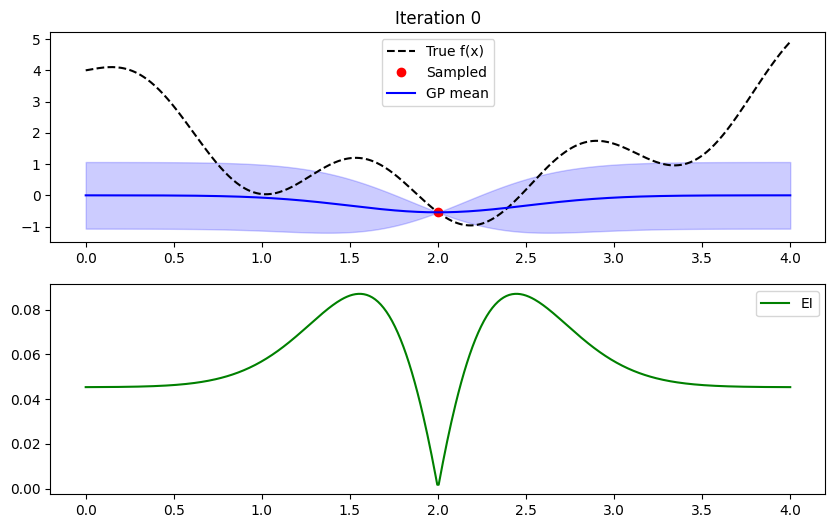

In [14]:
xx = np.linspace(a, b, 500).reshape(-1,1)
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 0")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
plt.legend()
plt.show()

### 5.4 - Show EI interval estimation in 2 subdomains

In [ ]:
iy = 0
intervals1, sampledMask1, excludedMask1Pre = split_intervals(intervals0, excludedMask0Post, a, b)
#for L,R in intervals1:
for i in range(len(intervals1)):
    L,R = intervals1[i]
    if sampledMask1[i]:
        print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
        print(f"Value is f({0.5*(L+R):.2f}) = {float(y.ravel()[iy]):.4f}")
        iy += 1
    else:
        mask = ((xx >= L) & (xx <= R)).ravel()

    #f_min = float(y.min())
    #gp_params = gp.kernel_.get_params()
    #sigma_f2 = float(gp_params['k1__constant_value'])
    #ell = float(gp_params['k2__length_scale'])
    #sigma_n2 = gp.alpha

    #out = ei_bounds_on_interval(L, R, X, y, f_min, sigma_f2, ell, sigma_n2)
        out = ei_bounds_on_interval(L, R, gp)
        print(f"\nInterval [{L:.2f}, {R:.2f}]:")
        print("μ bounds :", out["mu_bounds"])
        print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
        print("σ bounds :", out["sigma_bounds"])
        print("Q bounds :", out["Q_bounds"])
        print("EI bounds:", out["EI_bounds"])


Interval [0.00, 1.50]:
μ bounds : (-0.32996436840130267, -0.0001824981348684622)
Actual μ bounds : (-0.3293031180467831, -0.0001824981348684622)
σ bounds : (0.43253281370092495, 0.5440247415223307)
Q bounds : (3.3306130057116645e-08, 0.10887831776652981)
EI bounds: (-0.11042614781449743, 0.17853829205646704)

Interval [1.50, 2.50] Sampled
Value is f(2.00) = -0.5440

Interval [2.50, 4.00]:
μ bounds : (-0.32996436840130267, -0.0001824981348684622)
Actual μ bounds : (-0.3293031180467832, -0.0001824981348684622)
σ bounds : (0.43253281370092495, 0.5440247415223307)
Q bounds : (3.3306130057116645e-08, 0.10887831776652981)
EI bounds: (-0.11042614781449743, 0.17853829205646704)


### 5.5 - Decide if Excluding Subdomains

In [21]:
excludedMask1Post = np.array([0,0,0], dtype=bool)

## 6 - Iteration 1

### 6.1 - Sample function at the midpoint of the feasible subdomains

In [17]:
print("Iteration 1:")
print("intervals1:\n", intervals1)
print("sampledMask1:", sampledMask1.astype(int))
print("excludedMask1Pre:", excludedMask1Pre.astype(int))
print("bounded EI on:\n", intervals1[np.logical_and(np.logical_not(excludedMask1Pre),np.logical_not(sampledMask1))])
print("excludedMask1Post:", excludedMask1Post.astype(int))
print("x to sample:\n", interval_midpoints(intervals1[np.logical_not(excludedMask1Post)]))

X = interval_midpoints(intervals1[np.logical_not(excludedMask1Post)])
y = f(X)
print("y values:\n", y)

#X = np.vstack([X, X_new])
#y = np.vstack([y, y_new])

Iteration 1:
intervals1:
 [[0.  1.5]
 [1.5 2.5]
 [2.5 4. ]]
sampledMask1: [0 1 0]
excludedMask1Pre: [0 0 0]
bounded EI on:
 [[0.  1.5]
 [2.5 4. ]]
excludedMask1Post: [0 0 0]
x to sample:
 [[0.75]
 [2.  ]
 [3.25]]
y values:
 [[ 0.99093868]
 [-0.54402111]
 [ 1.04661815]]


### 6.2 - Build GP

In [18]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 6.3 - Plot

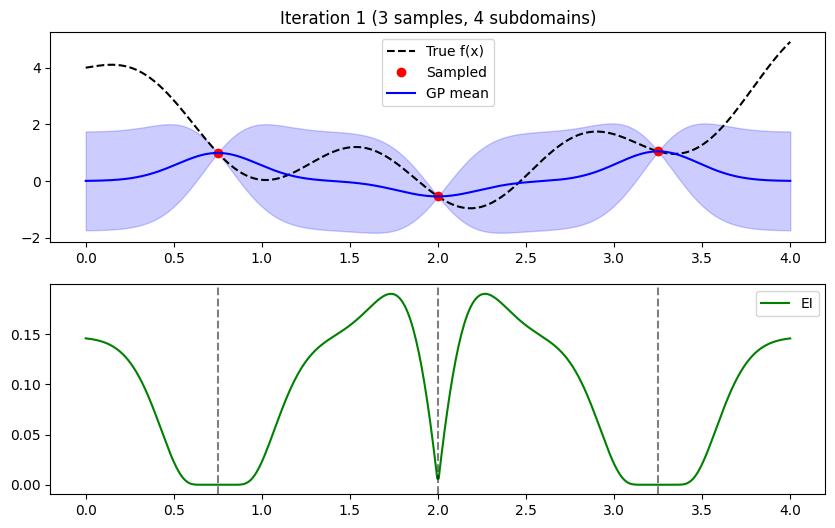

In [19]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 1 (3 samples, 4 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
for xvline in X.ravel():
    plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
#plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

### 6.4 - Show EI interval estimation in 4 subdomains

In [20]:
iy = 0
intervals2, sampledMask2, excludedMask2Pre = split_intervals(intervals1, excludedMask1Post, a, b)
for i in range(len(intervals2)):
    L,R = intervals2[i]
    if sampledMask2[i]:
        print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
        print(f"Value is f({0.5*(L+R):.2f}) = {float(y.ravel()[iy]):.4f}")
        iy += 1
    else:
        mask = ((xx >= L) & (xx <= R)).ravel()

        out = ei_bounds_on_interval(L, R, gp)
        print(f"\nInterval [{L:.2f}, {R:.2f}]:")
        print("μ bounds :", out["mu_bounds"])
        print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
        print("σ bounds :", out["sigma_bounds"])
        print("Q bounds :", out["Q_bounds"])
        print("EI bounds:", out["EI_bounds"])


Interval [0.00, 0.56]:
μ bounds : (0.0049242855101565754, 0.7113197939471185)
Actual μ bounds : (0.004924287383887143, 0.7078498742146803)
σ bounds : (0.6192655750250047, 0.889452057053443)
Q bounds : (1.9536618213943935e-05, 0.4076546460037655)
EI bounds: (-0.30547860523471204, 0.28160029317181473)

Interval [0.56, 0.94] Sampled
Value is f(0.75) = 0.9909

Interval [0.94, 1.69]:
μ bounds : (-0.21635529725716673, 0.7113068457732946)
Actual μ bounds : (-0.21108947120647809, 0.7103612453327448)
σ bounds : (0.5080081439110741, 0.889463011008756)
Q bounds : (5.046205273230785e-08, 0.5330722241348406)
EI bounds: (-0.43769596409796646, 0.3293585185411523)

Interval [1.69, 2.31] Sampled
Value is f(2.00) = -0.5440

Interval [2.31, 3.06]:
μ bounds : (-0.21634129626799278, 0.751274910969553)
Actual μ bounds : (-0.21107441110130487, 0.7502761840710637)
σ bounds : (0.5080081438594519, 0.8894630110382395)
Q bounds : (5.040960376695888e-08, 0.5330722241872896)
EI bounds: (-0.45364357883594003, 0.329

### 6.5 - Decide if Excluding Subdomains

In [22]:
excludedMask2Post = np.array([0,0,0,0,0,0,0], dtype=bool)

## 7 - Iteration 2

### 7.1 - Sample point at the midpoint of the feasible subdomains

In [23]:
print("Iteration 2:")
print("intervals2:\n", intervals2)
print("sampledMask2:", sampledMask2.astype(int))
print("excludedMask2Pre:", excludedMask2Pre.astype(int))
print("bounded EI on:\n", intervals2[np.logical_and(np.logical_not(excludedMask2Pre),np.logical_not(sampledMask2))])
print("excludedMask2Post:", excludedMask2Post.astype(int))
print("x to sample:\n", interval_midpoints(intervals2[np.logical_not(excludedMask2Post)]))

X = interval_midpoints(intervals2[np.logical_not(excludedMask2Post)])
y = f(X)
print("y values:\n", y)

Iteration 2:
intervals2:
 [[0.     0.5625]
 [0.5625 0.9375]
 [0.9375 1.6875]
 [1.6875 2.3125]
 [2.3125 3.0625]
 [3.0625 3.4375]
 [3.4375 4.    ]]
sampledMask2: [0 1 0 1 0 1 0]
excludedMask2Pre: [0 0 0 0 0 0 0]
bounded EI on:
 [[0.     0.5625]
 [0.9375 1.6875]
 [2.3125 3.0625]
 [3.4375 4.    ]]
excludedMask2Post: [0 0 0 0 0 0 0]
x to sample:
 [[0.28125]
 [0.75   ]
 [1.3125 ]
 [2.     ]
 [2.6875 ]
 [3.25   ]
 [3.71875]]
y values:
 [[ 3.94059433]
 [ 0.99093868]
 [ 0.74835322]
 [-0.54402111]
 [ 1.23771296]
 [ 1.04661815]
 [ 2.70107638]]


### 7.2 - Build GP

In [24]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 7.3 - Plot

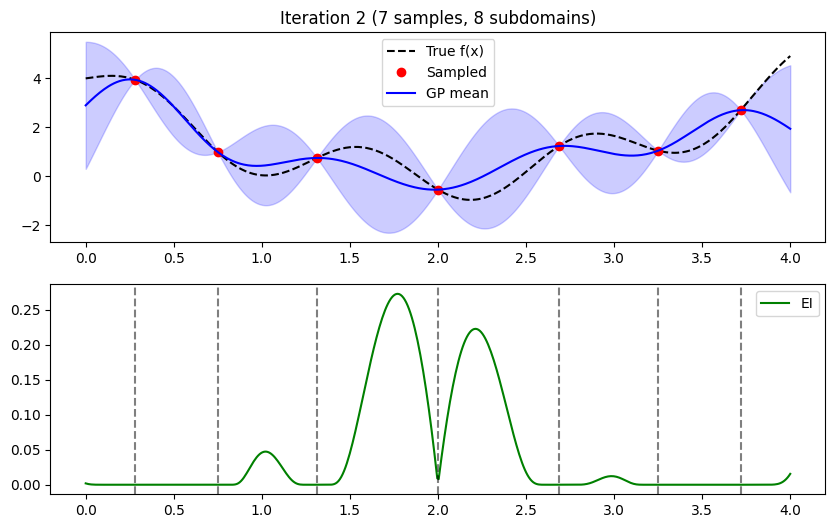

In [31]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 2 (7 samples, 8 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
for xvline in X.ravel():
    plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
#plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

### 7.4 - Show EI interval estimation in 8 subdomains

In [28]:
iy = 0
intervals3, sampledMask3, excludedMask3Pre = split_intervals(intervals2, excludedMask2Post, a, b)
for i in range(len(intervals3)):
    L,R = intervals3[i]
    if sampledMask3[i]:
        print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
        yx = float(y.ravel()[iy])
        print(f"Value is f({0.5*(L+R):.2f}) = {yx:.4f}")
        if yx == float(y.min()):
            print("**** This is the current best value.")
        iy += 1
    else:
        mask = ((xx >= L) & (xx <= R)).ravel()

        out = ei_bounds_on_interval(L, R, gp)
        print(f"\nInterval [{L:.2f}, {R:.2f}]:")
        print("μ bounds :", out["mu_bounds"])
        print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
        print("σ bounds :", out["sigma_bounds"])
        print("Q bounds :", out["Q_bounds"])
        print("EI bounds:", out["EI_bounds"])


Interval [0.00, 0.21]:
μ bounds : (2.742925728045889, 4.081870208674309)
Actual μ bounds : (2.8987115521314304, 3.921926864647477)
σ bounds : (0.0, 1.378764419667636)
Q bounds : (1.8210131368950584, 3.9297671035904256)
EI bounds: (0.0, 0.003935930055882126)

Interval [0.21, 0.35] Sampled
Value is f(0.28) = 3.9406

Interval [0.35, 0.63]:
μ bounds : (1.6689568582821745, 3.867406156245308)
Actual μ bounds : (1.8372379106334, 3.753537558103382)
σ bounds : (0.0, 1.5606836010114533)
Q bounds : (1.286271159370415, 5.994021731124848)
EI bounds: (0.0, 0.05500184147965673)

Interval [0.63, 0.87] Sampled
Value is f(0.75) = 0.9909

Interval [0.87, 1.17]:
μ bounds : (-0.2781740273921343, 1.4499374764198592)
Actual μ bounds : (0.4245083547961883, 0.6328843838058127)
σ bounds : (0.0, 1.7436514130706173)
Q bounds : (0.6816842115333309, 6.565803101725629)
EI bounds: (0.0, 0.5707621813530368)

Interval [1.17, 1.45] Sampled
Value is f(1.31) = 0.7484

Interval [1.45, 1.83]:
μ bounds : (-0.506380064360865

## 8. Optimization Loop